# 评估二：DDoS 攻击捕获与分析报告（Jupyter Notebook 附录）
**课程：单元三｜网络安全中的数据包分析**  
**提交人（姓名）：__________  学号：__________**  
**提交日期：2026-02-17 07:38**  

> 本 Notebook 用于支撑报告中的「数据处理与可视化证据」。  
> 你需要把本 Notebook 运行后的 **图表截图** 与 **Wireshark 操作截图** 一起放入 1500 字报告中。


## 合规与实验范围说明（必读）
- 本实验仅在 **本地/虚拟机环境** 中对 `localhost` 发起 SYN Flood（课程实验要求），用于学习流量特征与分析方法。  
- 不应将本 Notebook 或命令用于未授权目标或公网系统。  


## 0. 环境与文件准备
请把两份 Wireshark 导出的 CSV 放在 **与本 Notebook 同一目录**（或填写绝对路径）：

- `normal.csv`：正常环境（接口 `any`）抓包导出  
- `ddos_syn_flood_lo.csv`：攻击环境（接口 `Loopback: lo`）抓包导出

> ✅ 建议：Wireshark 导出时使用 `File -> Export Packet Dissections -> As CSV...`  
> - 勾选：Packet summary line（至少包含 No., Time, Source, Destination, Protocol, Length, Info）  
> - 如果文件很大（几百万行），导出可能较慢，属于正常现象。


In [1]:
# 1) 基础库
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 2) 可选：Seaborn（更好看的统计图）
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)


In [2]:
# =========================
# 你只需要改这里的文件名
# =========================
NORMAL_FILE = "normal.csv"
ATTACK_FILE = "ddos_syn_flood_lo.csv"

# 绘图/统计的通用参数
TIME_BINS_LINE = 15                 # 折线图：分成 15 段
TIME_BIN_SECONDS_BAR = 0.5          # 柱状图：每 0.5 秒一个区间
BAR_WINDOW_SECONDS = 3.5            # 只画 0~3.5 秒（题目要求 7 个区间）
ATTACK_SAMPLE_FOR_DIST = 200_000    # 分布类图（直方/KDE）对攻击数据做采样，避免卡死
RANDOM_SEED = 42


## 1. 读取与预处理

In [3]:
def _standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """把常见字段标准化，并做类型转换，减少后续出错。"""
    # 统一列名（去掉空白）
    df.columns = [c.strip() for c in df.columns]

    required = ["No.", "Time", "Source", "Destination", "Protocol", "Length", "Info"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"CSV 缺少必要列：{missing}\n当前列：{list(df.columns)}")

    # 类型转换
    df["No."] = pd.to_numeric(df["No."], errors="coerce")
    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
    df["Length"] = pd.to_numeric(df["Length"], errors="coerce")

    # 基础清洗
    df = df.dropna(subset=["No.", "Time", "Protocol", "Length"]).copy()
    df["Protocol"] = df["Protocol"].astype(str)

    return df

def load_csv(path: str, usecols=None, dtype=None) -> pd.DataFrame:
    """读取 CSV。对大文件可按需设置 usecols/dtype 提升速度。"""
    if not os.path.exists(path):
        raise FileNotFoundError(f"找不到文件：{path}（请确认放在同目录或填写正确路径）")
    df = pd.read_csv(path, usecols=usecols, dtype=dtype, low_memory=False)
    return _standardize_columns(df)

# 读取两份数据
df_normal = load_csv(NORMAL_FILE)
df_attack = load_csv(ATTACK_FILE)

print("✅ 数据读入完成")
print("Normal shape:", df_normal.shape)
print("Attack shape:", df_attack.shape)


✅ 数据读入完成
Normal shape: (11534, 7)
Attack shape: (2320270, 7)


In [4]:
# 基本概览（用于报告中的“过程/结果”描述）
def dataset_overview(df: pd.DataFrame, name: str):
    duration = df["Time"].max() - df["Time"].min()
    proto_counts = df["Protocol"].value_counts().head(10)
    print(f"\n--- {name} ---")
    print(f"Time range: {df['Time'].min():.6f} ~ {df['Time'].max():.6f} (duration ≈ {duration:.3f}s)")
    print(f"Packets: {len(df):,}")
    print("Top protocols:\n", proto_counts)

dataset_overview(df_normal, "Normal")
dataset_overview(df_attack, "Attack")



--- Normal ---
Time range: 0.000000 ~ 85.134456 (duration ≈ 85.134s)
Packets: 11,534
Top protocols:
 Protocol
QUIC       9828
TCP         777
TLSv1.3     711
DNS         200
ARP          16
TLSv1.2       2
Name: count, dtype: int64

--- Attack ---
Time range: 0.000000 ~ 4.735496 (duration ≈ 4.735s)
Packets: 2,320,270
Top protocols:
 Protocol
TCP    2320270
Name: count, dtype: int64


## 2. 通用绘图函数（更稳定、更少 bug）
下面我们用“按时间分箱统计”的方式生成题目要求的折线图与柱状图。  
这样不会依赖 `No.` 是否连续，也能避免你原本 for-loop 容易 off-by-one 的问题。


In [5]:
def packets_per_timebin(df: pd.DataFrame, bin_edges: np.ndarray) -> pd.Series:
    """统计每个时间区间内的封包数量（所有协议）。"""
    # pd.cut 会返回每个包落在哪个区间
    bins = pd.cut(df["Time"], bins=bin_edges, include_lowest=True)
    counts = bins.value_counts().sort_index()
    return counts

def tcp_packets_per_timebin(df: pd.DataFrame, bin_edges: np.ndarray) -> pd.Series:
    """统计每个时间区间内的 TCP 封包数量。"""
    tcp = df[df["Protocol"] == "TCP"]
    bins = pd.cut(tcp["Time"], bins=bin_edges, include_lowest=True)
    counts = bins.value_counts().sort_index()
    return counts

def pretty_bin_labels(interval_index) -> list:
    """把 pandas interval 变成好读的 x 轴标签。"""
    labels = []
    for itv in interval_index:
        labels.append(f"{itv.left:.1f}-{itv.right:.1f}s")
    return labels

def safe_sample(series: pd.Series, n: int, seed: int = 42) -> np.ndarray:
    """对超大数据做采样（用于分布图），避免画图卡死。"""
    if len(series) <= n:
        return series.dropna().to_numpy()
    return series.dropna().sample(n=n, random_state=seed).to_numpy()


## 3. 题目要求的 4 张图（必做）
- 图1：正常环境折线图（x=时间，y=封包数量）
- 图2：攻击环境折线图（x=时间，y=封包数量）
- 图3：正常环境柱状图（0–3.5s，7 个区间，y=TCP 封包数量）
- 图4：攻击环境柱状图（0–3.5s，7 个区间，y=TCP 封包数量）

> 说明：  
> - 折线图我们画 **“每个时间段的封包数”**（而不是 `No.` 直接当 y），更符合“数量随时间变化”的语义。  
> - 如果你一定要“累计封包数”也可以，我在下面额外给出累计版本（加分）。


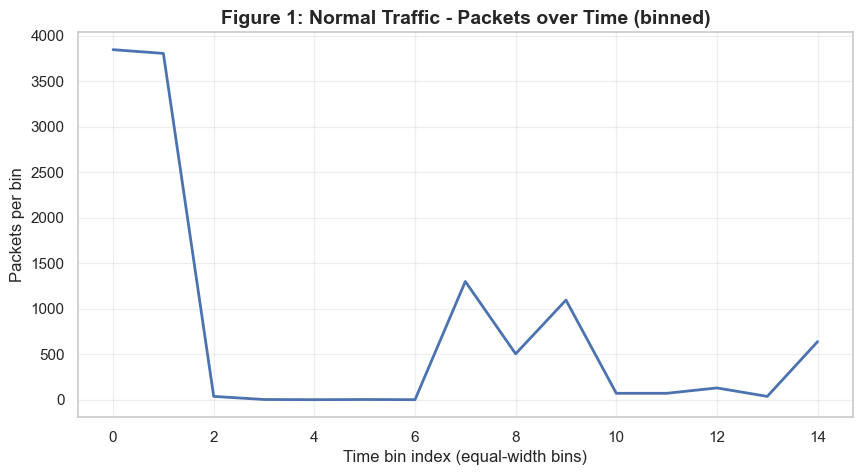

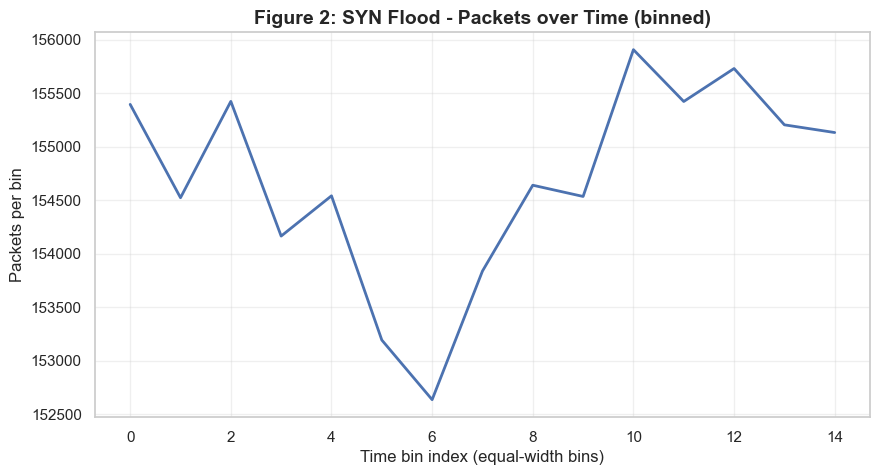

In [6]:
# ===== 图1/图2：折线图（每段时间内封包数） =====
def plot_line_packets(df: pd.DataFrame, title: str, bins: int = TIME_BINS_LINE):
    t_min, t_max = df["Time"].min(), df["Time"].max()
    edges = np.linspace(t_min, t_max, bins + 1)  # bins 段 -> bins+1 个边界
    counts = packets_per_timebin(df, edges)

    x = np.arange(len(counts))
    plt.figure(figsize=(10, 5))
    plt.plot(x, counts.values, linewidth=2)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Time bin index (equal-width bins)")
    plt.ylabel("Packets per bin")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_line_packets(df_normal, "Figure 1: Normal Traffic - Packets over Time (binned)")
plot_line_packets(df_attack, "Figure 2: SYN Flood - Packets over Time (binned)")


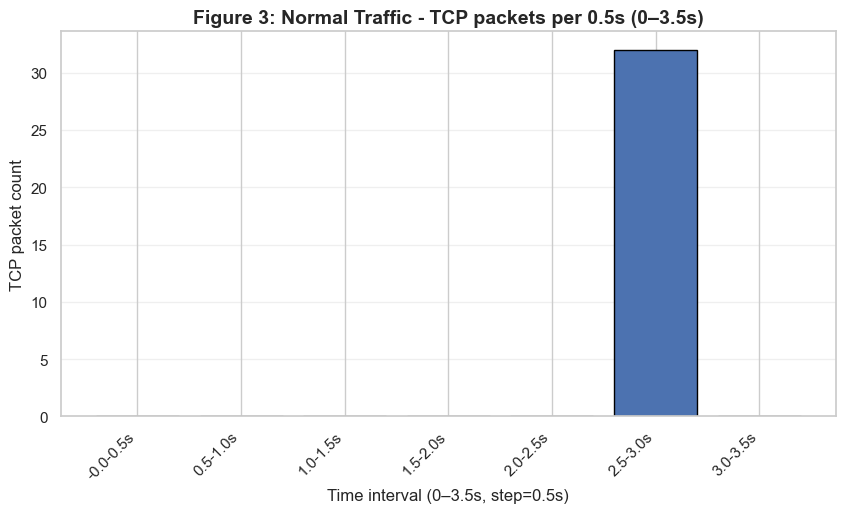

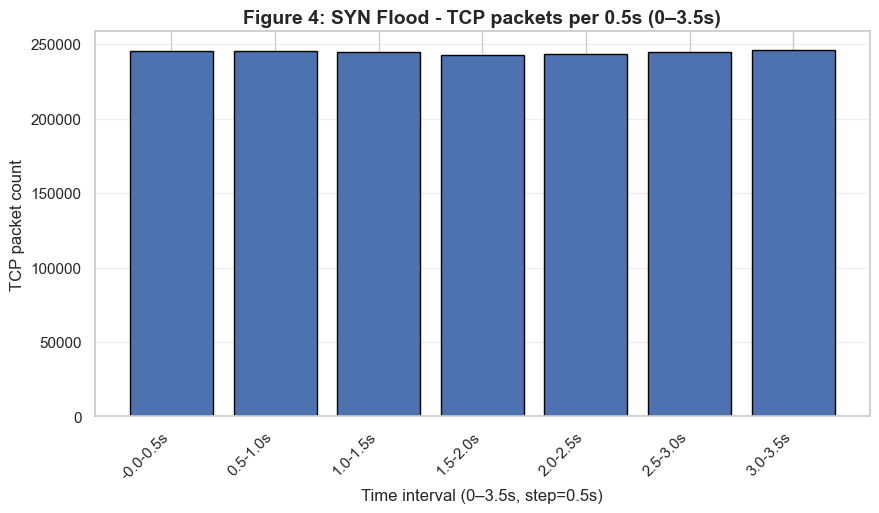

In [7]:
# ===== 图3/图4：柱状图（0~3.5s，每 0.5s 的 TCP 封包数） =====
def plot_bar_tcp(df: pd.DataFrame, title: str):
    # 仅取 0~3.5s 范围
    df_win = df[(df["Time"] >= 0) & (df["Time"] <= BAR_WINDOW_SECONDS)].copy()
    edges = np.arange(0, BAR_WINDOW_SECONDS + TIME_BIN_SECONDS_BAR, TIME_BIN_SECONDS_BAR)
    counts = tcp_packets_per_timebin(df_win, edges)

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(counts)), counts.values, edgecolor="black")
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Time interval (0–3.5s, step=0.5s)")
    plt.ylabel("TCP packet count")
    plt.xticks(range(len(counts)), pretty_bin_labels(counts.index), rotation=45, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

plot_bar_tcp(df_normal, "Figure 3: Normal Traffic - TCP packets per 0.5s (0–3.5s)")
plot_bar_tcp(df_attack, "Figure 4: SYN Flood - TCP packets per 0.5s (0–3.5s)")


### （加分）累计封包数折线图（更直观展示“飙升”）
这张图更像你原本的 Figure 1/2（`No.` 随时间增加），但我们用 **累计计数** 更稳健。


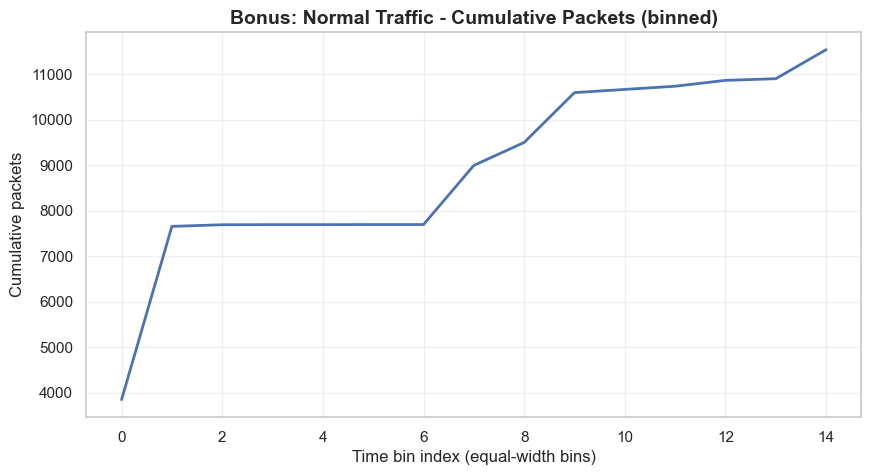

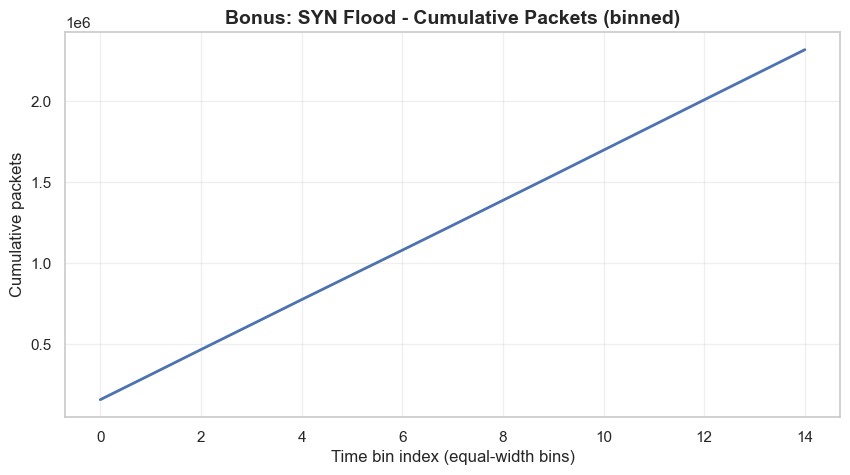

In [8]:
def plot_cumulative(df: pd.DataFrame, title: str, bins: int = TIME_BINS_LINE):
    t_min, t_max = df["Time"].min(), df["Time"].max()
    edges = np.linspace(t_min, t_max, bins + 1)
    counts = packets_per_timebin(df, edges)
    cumulative = counts.cumsum()

    plt.figure(figsize=(10, 5))
    plt.plot(range(len(cumulative)), cumulative.values, linewidth=2)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Time bin index (equal-width bins)")
    plt.ylabel("Cumulative packets")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_cumulative(df_normal, "Bonus: Normal Traffic - Cumulative Packets (binned)")
plot_cumulative(df_attack, "Bonus: SYN Flood - Cumulative Packets (binned)")


## 4. 进阶分析（用于“结果分析 / 研究”拿高分）
建议你在报告里至少挑 **3~5 张**进阶图，并结合解释：
1. **协议分布**：SYN Flood 主要是 TCP  
2. **来源 IP 多样性**：`--rand-source` 会导致 Source IP 激增（IP spoofing 证据）  
3. **封包长度分布**：攻击封包长度常常高度集中（你这里 54 bytes 近乎固定）  
4. **包速率 PPS**（Packets Per Second）：攻击流量的 PPS 远高于正常  
5. **TCP Flags / SYN 比例**：如果 Info 中含 `SYN` 关键字，可估计 SYN 占比（Wireshark CSV 有时会包含）


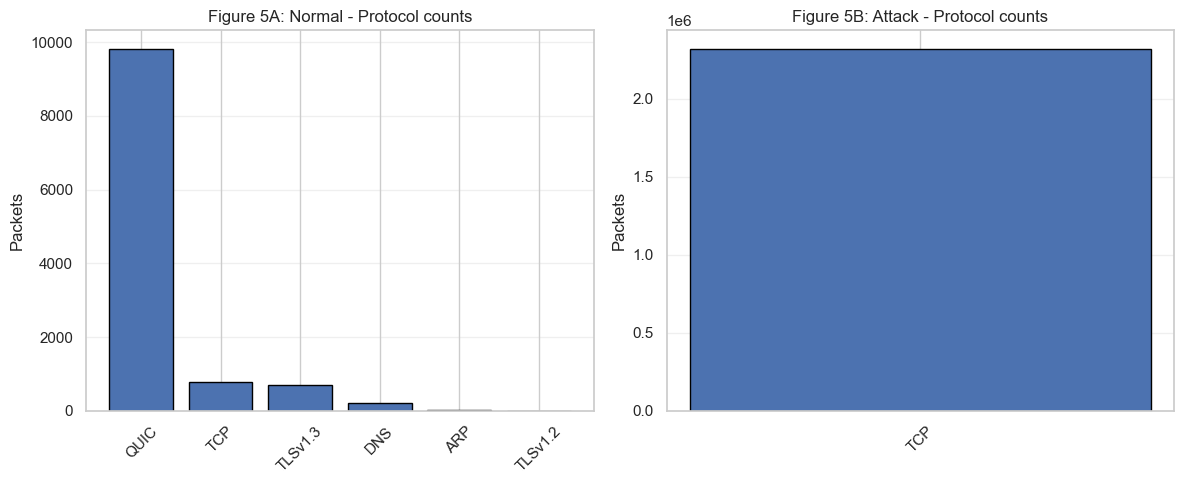

In [9]:
# Figure 5：协议分布（Normal vs Attack）
def plot_protocol_distribution(df_normal, df_attack):
    top_n = 8
    n_counts = df_normal["Protocol"].value_counts().head(top_n)
    a_counts = df_attack["Protocol"].value_counts().head(top_n)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].bar(n_counts.index, n_counts.values, edgecolor="black")
    ax[0].set_title("Figure 5A: Normal - Protocol counts")
    ax[0].tick_params(axis='x', rotation=45)

    ax[1].bar(a_counts.index, a_counts.values, edgecolor="black")
    ax[1].set_title("Figure 5B: Attack - Protocol counts")
    ax[1].tick_params(axis='x', rotation=45)

    for a in ax:
        a.set_ylabel("Packets")
        a.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_protocol_distribution(df_normal, df_attack)


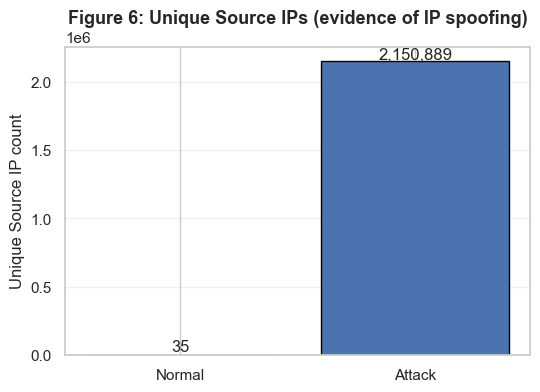

In [10]:
# Figure 6：Unique Source IP 对比（IP Spoofing 证据）
unique_ips_normal = df_normal["Source"].nunique()
unique_ips_attack = df_attack["Source"].nunique()

plt.figure(figsize=(6,4))
plt.bar(["Normal", "Attack"], [unique_ips_normal, unique_ips_attack], edgecolor="black")
plt.title("Figure 6: Unique Source IPs (evidence of IP spoofing)", fontsize=13, fontweight="bold")
plt.ylabel("Unique Source IP count")
for i, v in enumerate([unique_ips_normal, unique_ips_attack]):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


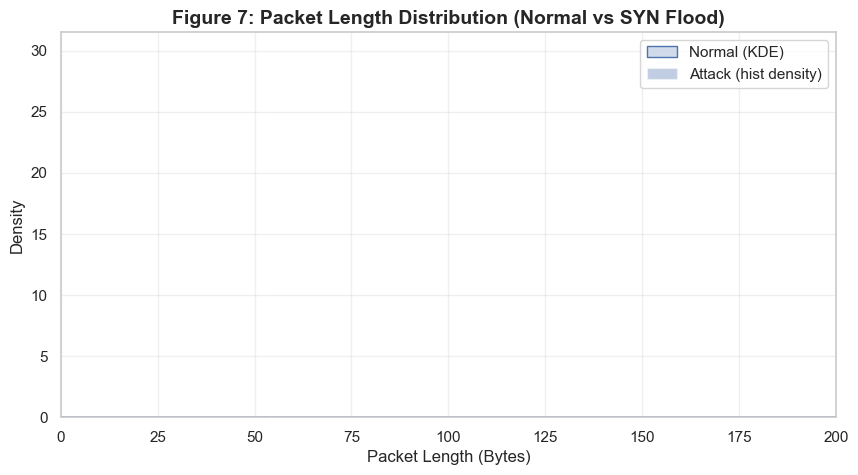

Normal Length variance: 8391761.65843316
Attack Length variance: 0.0


In [11]:
# Figure 7：封包长度分布（Normal vs Attack）
# 你的 attack Length variance = 0（几乎全是 54 bytes），KDE 会因为“零方差”画不出来，所以这里用直方图/条形密度更稳健。

# 采样，避免对 200 万行直接画图卡死
normal_len = safe_sample(df_normal["Length"], n=50_000, seed=RANDOM_SEED)
attack_len = safe_sample(df_attack["Length"], n=ATTACK_SAMPLE_FOR_DIST, seed=RANDOM_SEED)

plt.figure(figsize=(10,5))

# Normal：KDE 或直方图（如果 seaborn 不可用就用 matplotlib hist）
if sns is not None:
    sns.kdeplot(normal_len, label="Normal (KDE)", fill=True, alpha=0.25)
else:
    plt.hist(normal_len, bins=50, density=True, alpha=0.25, label="Normal")

# Attack：用直方图（密度），因为基本是单点
plt.hist(attack_len, bins=30, density=True, alpha=0.35, label="Attack (hist density)")

plt.title("Figure 7: Packet Length Distribution (Normal vs SYN Flood)", fontsize=14, fontweight="bold")
plt.xlabel("Packet Length (Bytes)")
plt.ylabel("Density")
plt.xlim(0, 200)  # 攻击在 54 bytes，放大观察（报告里更有说服力）
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Normal Length variance:", float(pd.Series(normal_len).var()))
print("Attack Length variance:", float(pd.Series(attack_len).var()))


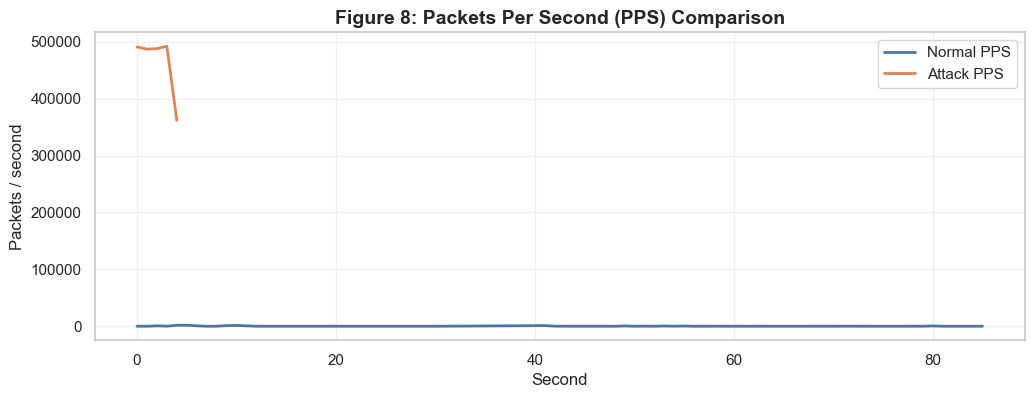

Normal peak PPS: 1806
Attack peak PPS: 492255


In [12]:
# Figure 8：Packets Per Second (PPS) - 更直接的 DDoS 证据
def packets_per_second(df: pd.DataFrame) -> pd.Series:
    # 向下取整到“秒”
    sec = np.floor(df["Time"]).astype(int)
    return pd.Series(sec).value_counts().sort_index()

pps_normal = packets_per_second(df_normal)
pps_attack = packets_per_second(df_attack)

plt.figure(figsize=(12,4))
plt.plot(pps_normal.index, pps_normal.values, linewidth=2, label="Normal PPS")
plt.plot(pps_attack.index, pps_attack.values, linewidth=2, label="Attack PPS")
plt.title("Figure 8: Packets Per Second (PPS) Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Second")
plt.ylabel("Packets / second")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Normal peak PPS:", int(pps_normal.max()) if len(pps_normal) else 0)
print("Attack peak PPS:", int(pps_attack.max()) if len(pps_attack) else 0)


TCP ratio - Normal: 0.06736604820530605
TCP ratio - Attack: 1.0
SYN keyword ratio - Normal: 0.006675914687012311
SYN keyword ratio - Attack: 0.9308843367366729


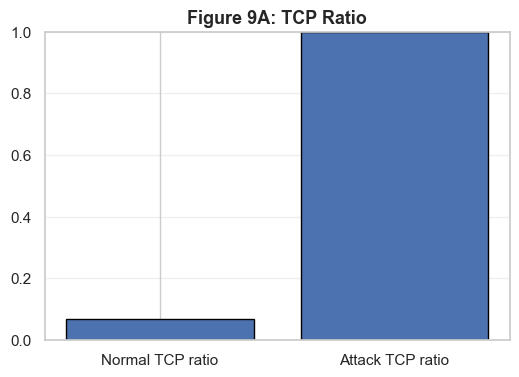

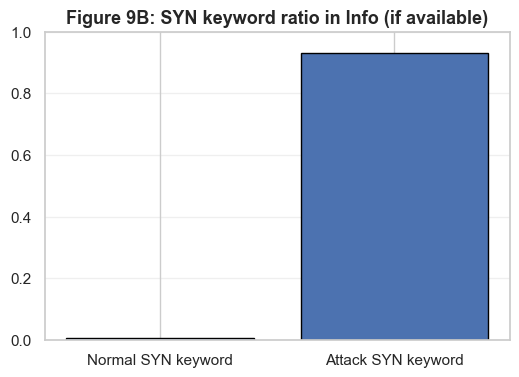

In [13]:
# Figure 9：TCP 占比 + Info 里 SYN 关键字比例（如果可用）
def tcp_ratio(df: pd.DataFrame) -> float:
    return float((df["Protocol"] == "TCP").mean())

def syn_keyword_ratio(df: pd.DataFrame) -> float:
    # Wireshark CSV 的 Info 字段通常包含 flags，如 [SYN]、SYN, ACK 等
    info = df["Info"].astype(str)
    return float(info.str.contains("SYN", case=False, na=False).mean())

print("TCP ratio - Normal:", tcp_ratio(df_normal))
print("TCP ratio - Attack:", tcp_ratio(df_attack))

# 只有当 Info 字段确实包含 SYN 才有意义
syn_n = syn_keyword_ratio(df_normal)
syn_a = syn_keyword_ratio(df_attack)
print("SYN keyword ratio - Normal:", syn_n)
print("SYN keyword ratio - Attack:", syn_a)

plt.figure(figsize=(6,4))
plt.bar(["Normal TCP ratio","Attack TCP ratio"], [tcp_ratio(df_normal), tcp_ratio(df_attack)], edgecolor="black")
plt.title("Figure 9A: TCP Ratio", fontsize=13, fontweight="bold")
plt.ylim(0,1)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(6,4))
plt.bar(["Normal SYN keyword","Attack SYN keyword"], [syn_n, syn_a], edgecolor="black")
plt.title("Figure 9B: SYN keyword ratio in Info (if available)", fontsize=13, fontweight="bold")
plt.ylim(0,1)
plt.grid(True, axis="y", alpha=0.3)
plt.show()


## 5. 可直接放入报告的“关键结论点”（你运行后补数字）
运行完上面的图后，把以下要点融入报告「结果分析」段落（每点 2~4 句）：

- **流量规模差异**：Attack 包总数远大于 Normal，且 Attack 的 PPS 峰值显著更高（见 Figure 8）。  
- **协议特征**：Attack 主要集中在 TCP（见 Figure 5/9A），符合 SYN Flood 行为。  
- **封包大小集中**：Attack 的 Length 几乎固定（你这里约 54 bytes），variance≈0，说明是自动化重复请求而非正常访问（见 Figure 7）。  
- **IP Spoofing 证据**：Attack 的 Source IP 唯一数明显更高（见 Figure 6），与 `--rand-source` 一致。  
- **为什么会过载**：SYN Flood 会占用服务器半连接队列资源（SYN backlog），导致正常连接被延迟/拒绝。  

> 提醒：报告的“研究”部分要另找一种不同于 SYN Flood 的 DDoS 类型，并给真实案例+应对措施。


## 6. 参考文献/资料（报告里用）
- Wireshark 官方文档
- hping3/网络安全教材
- 你选择的 DDoS 案例新闻/报告（请在报告中按学校格式引用）